In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

In [86]:
train_data = pd.read_csv("C:\\Users\\sepeh\\Desktop\\train.csv")

test_data = pd.read_csv("C:\\Users\\sepeh\\Desktop\\test.csv")

sample_submission = pd.read_csv("C:\\Users\\sepeh\\Desktop\\sample_submission.csv")
train_data.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [87]:
print(len(test_data['id']))

800000


In [88]:
train_data.shape
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [89]:
num = []
cat = []

for col in train_data.columns:
    if train_data[col].dtype == "object":
        cat.append(col)
    else:
        num.append(col)
num.remove("Premium Amount")
num.remove("id")
print("numerical columns : " + str(num))
print("categorical columns : " + str(cat))
train_data.isnull().sum()

numerical columns : ['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration']
categorical columns : ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [90]:
for col in cat:
    print(train_data[col].value_counts())
    print("-------------------")

Gender
Male      602571
Female    597429
Name: count, dtype: int64
-------------------
Marital Status
Single      395391
Married     394316
Divorced    391764
Name: count, dtype: int64
-------------------
Education Level
Master's       303818
PhD            303507
Bachelor's     303234
High School    289441
Name: count, dtype: int64
-------------------
Occupation
Employed         282750
Self-Employed    282645
Unemployed       276530
Name: count, dtype: int64
-------------------
Location
Suburban    401542
Rural       400947
Urban       397511
Name: count, dtype: int64
-------------------
Policy Type
Premium          401846
Comprehensive    399600
Basic            398554
Name: count, dtype: int64
-------------------
Policy Start Date
2020-02-08 15:21:39.134960    142
2023-08-13 15:21:39.155231    137
2022-02-02 15:21:39.134960    137
2022-08-30 15:21:39.134960    134
2023-11-02 15:21:39.134960    118
                             ... 
2021-06-07 15:21:39.104139      1
2024-07-19 15:21:3

In [91]:
num = []
cat = []

for col in train_data.columns:
    if train_data[col].dtype == "object":
        cat.append(col)
    else:
        num.append(col)
num.remove("Premium Amount")
num.remove("id")
print("numerical columns : " + str(num))
print("categorical columns : " + str(cat))

numerical columns : ['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration']
categorical columns : ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


In [92]:
train_data["Policy Start Date"] = pd.to_datetime(train_data["Policy Start Date"])
test_data["Policy Start Date"] = pd.to_datetime(test_data["Policy Start Date"])
train_data["year"] = train_data["Policy Start Date"].dt.year
num.append("year")
test_data["year"] = test_data["Policy Start Date"].dt.year
train_data["month"] = train_data["Policy Start Date"].dt.month
num.append("month")
test_data["month"] = test_data["Policy Start Date"].dt.month
train_data["day"] = train_data["Policy Start Date"].dt.day
num.append("day")
test_data["day"] = test_data["Policy Start Date"].dt.day
train_data = train_data.drop(columns=["Policy Start Date"])
cat.remove("Policy Start Date")
test_data = test_data.drop(columns=["Policy Start Date"])

In [93]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [94]:

class DateTimeFeaturesExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Ensure the date is in datetime format
        X_copy["Policy Start Date"] = pd.to_datetime(X_copy["Policy Start Date"])

        # Extract year, month, and day
        X_copy["year"] = X_copy["Policy Start Date"].dt.year
        X_copy["month"] = X_copy["Policy Start Date"].dt.month
        X_copy["day"] = X_copy["Policy Start Date"].dt.day
        print(X_copy.head())
        return X_copy.drop(columns=["Policy Start Date"])


In [95]:
train_data.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
year                         0
month                        0
day                          0
dtype: int64

In [96]:
num_imputer = SimpleImputer(strategy='mean')

train_data[num] = num_imputer.fit_transform(train_data[num])
test_data[num] = num_imputer.transform(test_data[num])
cat_imputer = SimpleImputer(strategy='most_frequent')
train_data[cat] = cat_imputer.fit_transform(train_data[cat])
test_data[cat] = cat_imputer.transform(test_data[cat])

In [97]:
train_data.isnull().sum()

id                      0
Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Occupation              0
Health Score            0
Location                0
Policy Type             0
Previous Claims         0
Vehicle Age             0
Credit Score            0
Insurance Duration      0
Customer Feedback       0
Smoking Status          0
Exercise Frequency      0
Property Type           0
Premium Amount          0
year                    0
month                   0
day                     0
dtype: int64

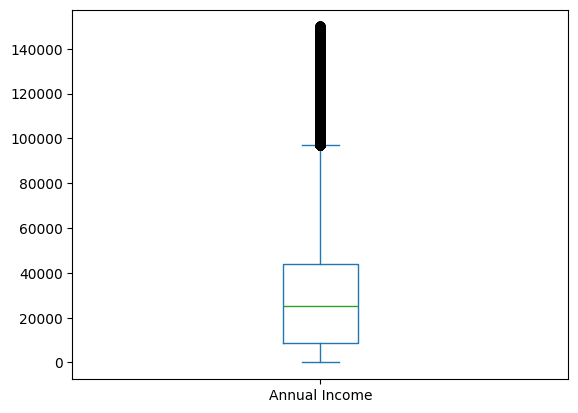

43936.0
8646.0


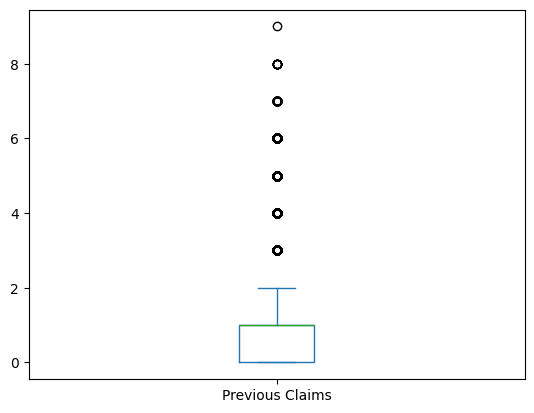

In [98]:
train_data["Annual Income"].plot(kind="box")
plt.show()
q3 = train_data["Annual Income"].quantile(0.75)
q1 = train_data["Annual Income"].quantile(0.25)
upper = q3 + (q3 - q1) * 1.5
print(q3)
print(q1)
43936.0
8646.0
train_data.loc[train_data["Annual Income"] > upper, "Annual Income"] = upper
train_data["Previous Claims"].plot(kind="box")
plt.show()

1.002689088497089
0.0


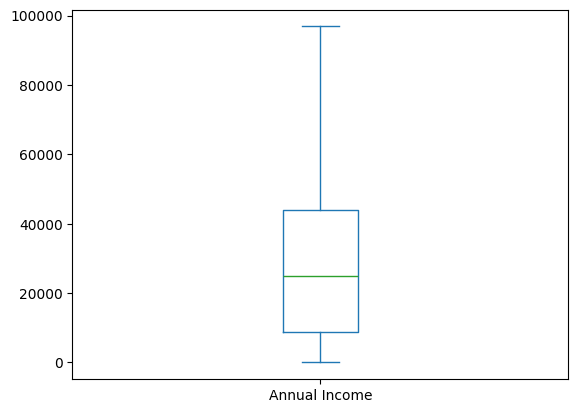

In [99]:
q3 = train_data["Previous Claims"].quantile(0.75)
q1 = train_data["Previous Claims"].quantile(0.25)
upper = q3 + (q3 - q1) * 1.5
print(q3)
print(q1)
1.002689088497089
0.0
train_data.loc[train_data["Previous Claims"] > upper, "Previous Claims"] = upper
train_data["Annual Income"].plot(kind="box")
plt.show()

In [100]:
# for col in cat :
#     temp=LabelEncoder()
#     train_data[col]=temp.fit_transform(train_data[col])


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False to return dense numpy array

# Loop through categorical columns
for col in cat:
    # Fit and transform the data for each categorical column
    encoded_values = encoder.fit_transform(train_data[[col]])  # Use double brackets to pass as DataFrame

    # Create new column names based on the original column and unique categories
    encoded_df = pd.DataFrame(encoded_values, columns=encoder.get_feature_names_out([col]))

    # Drop the original categorical column and concatenate the encoded columns
    train_data = pd.concat([train_data.drop(col, axis=1), encoded_df], axis=1)

    encoded_values = encoder.transform(test_data[[col]])

    # Create new column names based on the original column and unique categories
    encoded_df = pd.DataFrame(encoded_values, columns=encoder.get_feature_names_out([col]))

    # Drop the original categorical column and concatenate the encoded columns
    test_data = pd.concat([test_data.drop(col, axis=1), encoded_df], axis=1)

In [101]:
scaler = StandardScaler()

train_data[num] = scaler.fit_transform(train_data[num])
test_data[num] = scaler.transform(test_data[num])
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 43 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1200000 non-null  int64  
 1   Age                          1200000 non-null  float64
 2   Annual Income                1200000 non-null  float64
 3   Number of Dependents         1200000 non-null  float64
 4   Health Score                 1200000 non-null  float64
 5   Previous Claims              1200000 non-null  float64
 6   Vehicle Age                  1200000 non-null  float64
 7   Credit Score                 1200000 non-null  float64
 8   Insurance Duration           1200000 non-null  float64
 9   Premium Amount               1200000 non-null  float64
 10  year                         1200000 non-null  float64
 11  month                        1200000 non-null  float64
 12  day                          1200000 non-n

In [102]:
correlation_matrix = train_data.corr()
print(correlation_matrix)

print(correlation_matrix["Premium Amount"])

                                   id       Age  Annual Income  \
id                           1.000000 -0.000134      -0.000826   
Age                         -0.000134  1.000000       0.000043   
Annual Income               -0.000826  0.000043       1.000000   
Number of Dependents         0.000717  0.001395       0.002407   
Health Score                 0.001370  0.000847       0.024348   
Previous Claims             -0.000383  0.001453       0.030350   
Vehicle Age                 -0.001461 -0.002436      -0.000650   
Credit Score                 0.000915  0.002652      -0.189672   
Insurance Duration          -0.000350 -0.000063      -0.000144   
Premium Amount              -0.000292 -0.002411      -0.015816   
year                        -0.000912 -0.003152      -0.009417   
month                        0.000621  0.001195       0.008780   
day                         -0.000692 -0.000595       0.000375   
Gender_Female                0.001454 -0.000215       0.001189   
Gender_Mal

In [103]:

best_columns_train = ["id", "Premium Amount", "Annual Income", "Previous Claims", "Credit Score", "Health Score",
                      "year", "Customer Feedback_Average", "Customer Feedback_Good", "Customer Feedback_Poor"]
train_data = train_data[best_columns_train]
best_columns_test = best_columns_train.copy()
best_columns_test.remove("Premium Amount")

In [104]:
print(len(test_data['id']))

800000


In [105]:
# Filter test_data with the updated list
test_data = test_data[best_columns_test]
train_data = train_data.drop(columns=["id"])
id_test = test_data["id"]
test_data = test_data.drop(columns=["id"])
y = np.log1p(train_data["Premium Amount"])
X = train_data.drop(columns=["Premium Amount"])

In [115]:
best_params = {
    'colsample_bytree': 0.9,
    'learning_rate': 0.01,
    'max_depth': 9,
    'n_estimators': 600,
    'subsample': 0.75
}

# Create the XGBRegressor model with the correct parameters
model = xgb.XGBRegressor(**best_params)
X.isna().sum()

Annual Income                0
Previous Claims              0
Credit Score                 0
Health Score                 0
year                         0
Customer Feedback_Average    0
Customer Feedback_Good       0
Customer Feedback_Poor       0
dtype: int64

In [116]:
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=600, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [117]:
predict_train = model.predict(X)
print(np.sqrt(mean_squared_error(y, predict_train)))

predict_test = model.predict(test_data)
predict_test = np.expm1(predict_test)
rmse_test = np.sqrt(mean_squared_error(sample_submission['Premium Amount'], predict_test))
print(f'Rmse Test : {rmse_test}')
# # predicts=np.expm1(predict_test)
# results_df = pd.DataFrame({'id': id_test, 'Premium Amount': predict_test})
# 
# # Save the DataFrame to a CSV file
# results_df.to_csv('submission2.csv', index=False) 

1.0406493121914708
Rmse Test : 379.785850405582


In [113]:
print(len(id_test))
print(len(predicts))


800000
800000
